In [1]:
import pandas as pd

data=pd.read_csv("./dataset/train.csv")
test_data=pd.read_csv("./dataset/test.csv")

data.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [3]:
data.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


In [4]:
data.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [5]:
import numpy as np

cols = ['Temperature', 'RoadType', 'Weather']

for col in cols:
    data[col] = data[col].replace(['Nan', 'nan', 'NA', ''], np.nan)
    test_data[col] = test_data[col].replace(['Nan', 'nan', 'NA', ''], np.nan)

In [6]:
data['Temperature'] = pd.to_numeric(
    data['Temperature'],
    errors='coerce'
)

test_data['Temperature'] = pd.to_numeric(
    test_data['Temperature'],
    errors='coerce'
)

In [7]:
print(data[['Temperature','RoadType','Weather']].isnull().sum())
print(data['Temperature'].median())
print(data['RoadType'].mode()[0])
print(data['Weather'].mode()[0])

Temperature    2495
RoadType        600
Weather         797
dtype: int64
16.382587216677827
Residential
Sunny


In [8]:
data['Temperature'] = data['Temperature'].fillna(data['Temperature'].median())
test_data['Temperature'] = test_data['Temperature'].fillna(data['Temperature'].median())

data['RoadType'] = data['RoadType'].fillna(data['RoadType'].mode()[0])
test_data['RoadType'] = test_data['RoadType'].fillna(data['RoadType'].mode()[0])

data['Weather'] = data['Weather'].fillna(data['Weather'].mode()[0])
test_data['Weather'] = test_data['Weather'].fillna(data['Weather'].mode()[0])

In [9]:
print(data.isnull().sum())


Index            0
geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64


In [10]:
data[['hour', 'minute']] = data['timestamp'].str.split(':', expand=True)

data['hour'] = data['hour'].astype(int)
data['minute'] = data['minute'].astype(int)

test_data[['hour', 'minute']] = test_data['timestamp'].str.split(':', expand=True)

test_data['hour'] = test_data['hour'].astype(int)
test_data['minute'] = test_data['minute'].astype(int)

In [11]:
num_cols = ['demand', 'Temperature', 'NumberofLanes', 'hour', 'minute']

print(data[num_cols].describe())

             demand   Temperature  NumberofLanes          hour        minute
count  7.729900e+04  77299.000000   77299.000000  77299.000000  77299.000000
mean   9.394238e-02     16.404619       2.014334      9.101347     22.271310
std    1.421905e-01      7.240083       0.904665      6.856045     16.853641
min    6.245650e-07    -14.935097       1.000000      0.000000      0.000000
25%    1.822723e-02     11.624189       1.000000      3.000000      0.000000
50%    4.775994e-02     16.382587       2.000000      8.000000     15.000000
75%    1.085951e-01     21.115592       3.000000     14.000000     30.000000
max    1.000000e+00     48.251433       5.000000     23.000000     45.000000


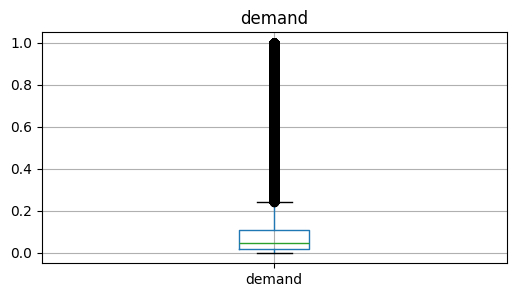

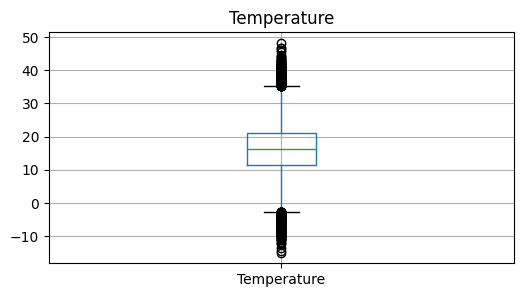

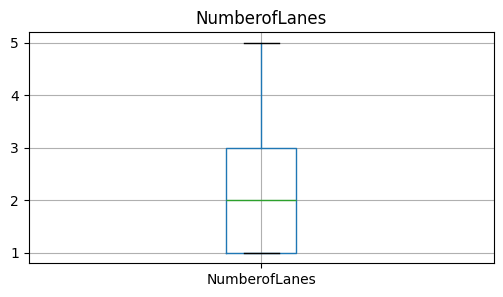

In [12]:
import matplotlib.pyplot as plt

for col in ['demand', 'Temperature', 'NumberofLanes']:
    plt.figure(figsize=(6,3))
    data.boxplot(column=col)
    plt.title(col)
    plt.show()

In [13]:
Q1 = data['demand'].quantile(0.25)
Q3 = data['demand'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[
    (data['demand'] < lower) |
    (data['demand'] > upper)
]

print("Outliers:", len(outliers))
print("Percentage:", len(outliers)/len(data)*100)

Outliers: 6413
Percentage: 8.296355709646955


In [14]:
outliers[['demand','hour','day','Weather']].head(20)

,demand,hour,day,Weather
56,0.271215,0,48,Rainy
209,0.291182,0,48,Sunny
230,0.344922,0,48,Sunny
253,0.290982,0,48,Foggy
277,0.399698,0,48,Sunny
299,0.316075,0,48,Snowy
300,0.526141,0,48,Foggy
326,0.391276,0,48,Sunny
327,1.000000,0,48,Sunny
328,0.302888,0,48,Foggy


In [15]:
Q1 = data['demand'].quantile(0.25)
Q3 = data['demand'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[
    (data['demand'] < lower) |
    (data['demand'] > upper)
]

print("Outliers:", len(outliers))
print("Percentage:", len(outliers)/len(data)*100)

Outliers: 6413
Percentage: 8.296355709646955


In [16]:
Q1 = data['Temperature'].quantile(0.25)
Q3 = data['Temperature'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

temp_outliers = data[
    (data['Temperature'] < lower) |
    (data['Temperature'] > upper)
]

print("Outliers:", len(temp_outliers))
print("Percentage:", len(temp_outliers)/len(data)*100)

Outliers: 758
Percentage: 0.9806077698288465


In [17]:
data['time_slot'] = data['hour'] * 4 + data['minute'] // 15
test_data['time_slot'] = test_data['hour'] * 4 + test_data['minute'] // 15

In [18]:
print(data['demand'].describe())

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


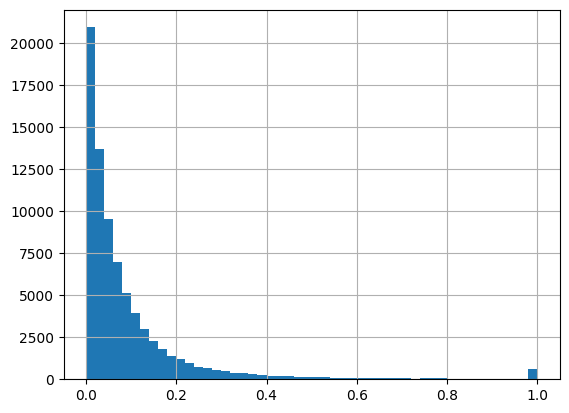

In [19]:
import matplotlib.pyplot as plt

data['demand'].hist(bins=50)
plt.show()

In [20]:
data['is_peak_hour'] = data['hour'].isin(
    [7,8,9,17,18,19]
).astype(int)

test_data['is_peak_hour'] = test_data['hour'].isin(
    [7,8,9,17,18,19]
).astype(int)

In [21]:
data['is_night'] = (
    (data['hour'] <= 5) |
    (data['hour'] >= 22)
).astype(int)

test_data['is_night'] = (
    (test_data['hour'] <= 5) |
    (test_data['hour'] >= 22)
).astype(int)

In [22]:
X = data.drop(
    ['demand', 'Index', 'timestamp'],
    axis=1
)

y = data['demand']

X_test = test_data.drop(
    ['Index', 'timestamp'],
    axis=1
)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
cat_features = X.select_dtypes(
    include=['object']
).columns.tolist()

print(cat_features)

['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']


In [25]:
from sklearn.metrics import r2_score

from catboost import CatBoostRegressor

model_catboost = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    verbose=100
)

model_catboost.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

preds_catboost = model_catboost.predict(X_val)

0:	learn: 0.1369035	total: 508ms	remaining: 8m 27s
100:	learn: 0.0438580	total: 19.3s	remaining: 2m 52s
200:	learn: 0.0399890	total: 40.7s	remaining: 2m 41s
300:	learn: 0.0376299	total: 1m 1s	remaining: 2m 21s
400:	learn: 0.0360412	total: 1m 20s	remaining: 2m
500:	learn: 0.0348333	total: 1m 45s	remaining: 1m 44s
600:	learn: 0.0340039	total: 2m 13s	remaining: 1m 28s
700:	learn: 0.0332362	total: 2m 37s	remaining: 1m 7s
800:	learn: 0.0325188	total: 3m 1s	remaining: 45.1s
900:	learn: 0.0319129	total: 3m 26s	remaining: 22.7s
999:	learn: 0.0313091	total: 3m 50s	remaining: 0us


In [26]:
print(
    "R2:",
    r2_score(y_val, preds_catboost)
)

R2: 0.9408799504898726


In [27]:
print(data.dtypes)
print(data['geohash'].nunique())
print(data['day'].unique())

Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
hour               int64
minute             int64
time_slot          int64
is_peak_hour       int64
is_night           int64
dtype: object
1249
[48 49]


In [28]:
# Create test feature matrix
X_test = test_data.drop(
    ['Index', 'timestamp'],
    axis=1,
    errors='ignore'
)

# Generate predictions
predictions = model.predict(X_test)

submission = pd.DataFrame({
    'Index': test_data['Index'],
    'demand': predictions
})

submission.to_csv('a.csv', index=False)

print("Saved successfully as a.csv")
print(submission.head())

NameError: name 'model' is not defined